# Uber Fare Prediction using Spatial Temporal Modeling

In [1]:
# Importing necessary libraries

# Data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

# Defining a random state
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("uber.csv")

In [3]:
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (200000, 9)


In [4]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [5]:
df.dtypes

Unnamed: 0             int64
key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

### Data Cleaning

In [6]:
# Checking duplicates (Before Cleaning)
df.duplicated().value_counts() / len(df) * 100

False    100.0
Name: count, dtype: float64

The False count is 100% meaning that there are no duplicate values in the dataset.

In [7]:
# Checking missing values (Before Cleaning)
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

Two columns: dropoff_longitude and dropoff_latitude have a missing value each, these can be dropped safely.

Outliers before cleaning: 


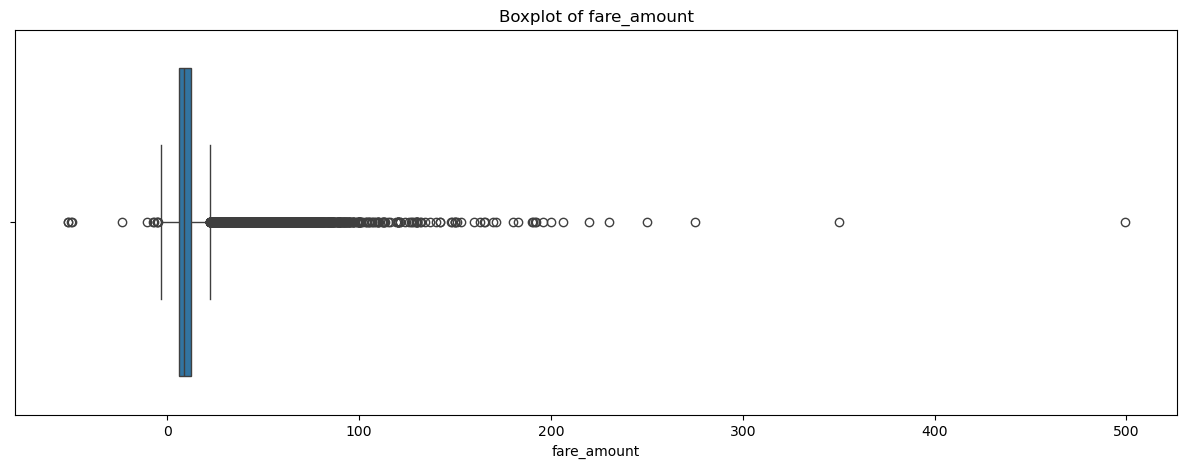

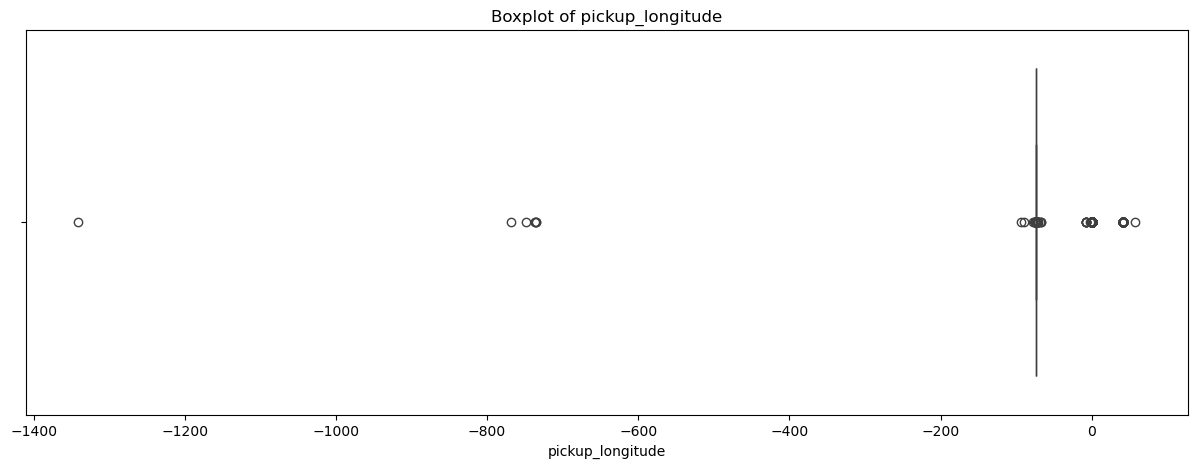

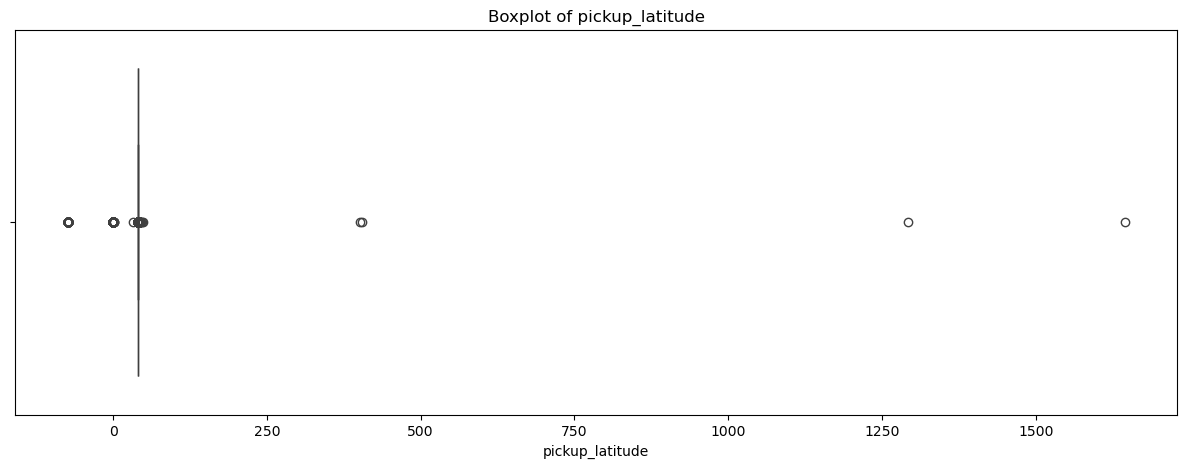

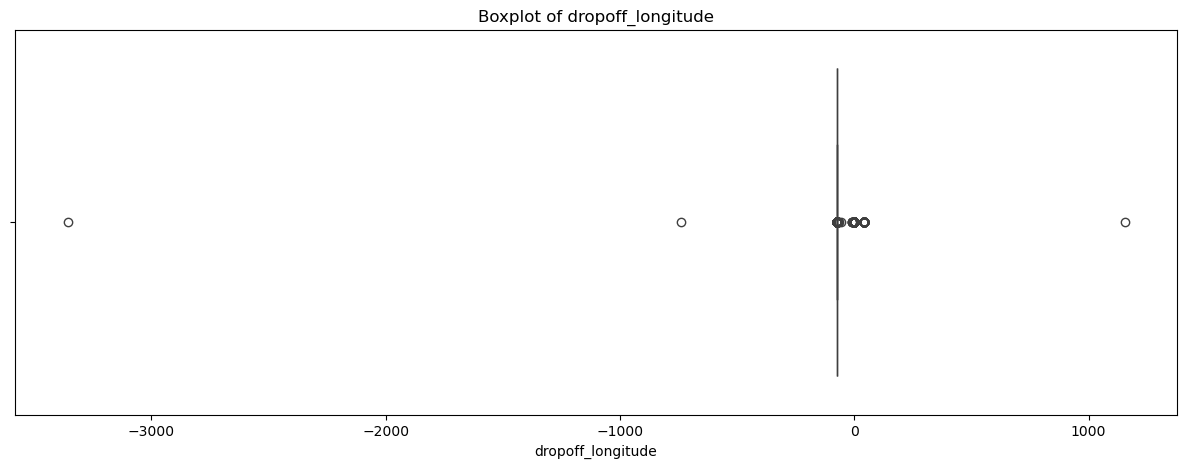

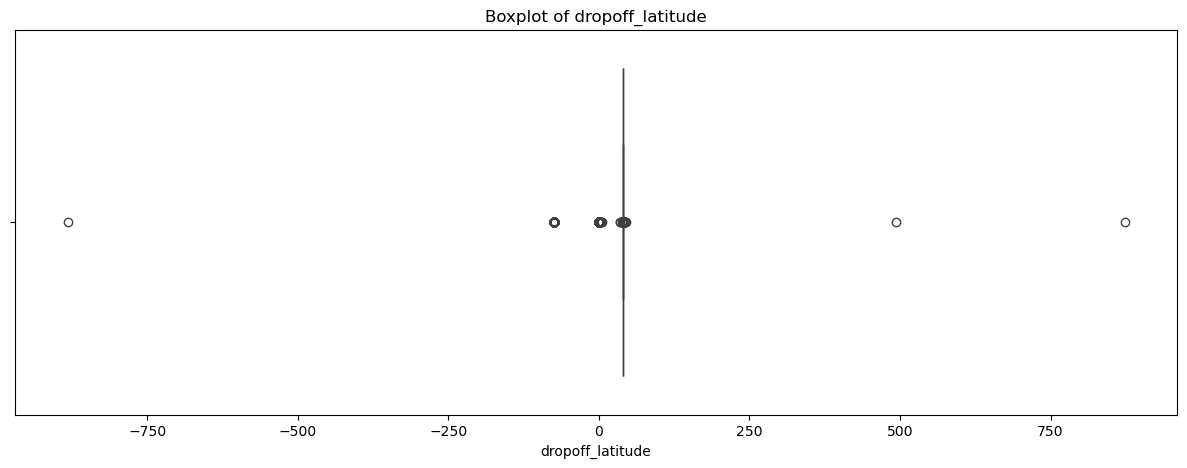

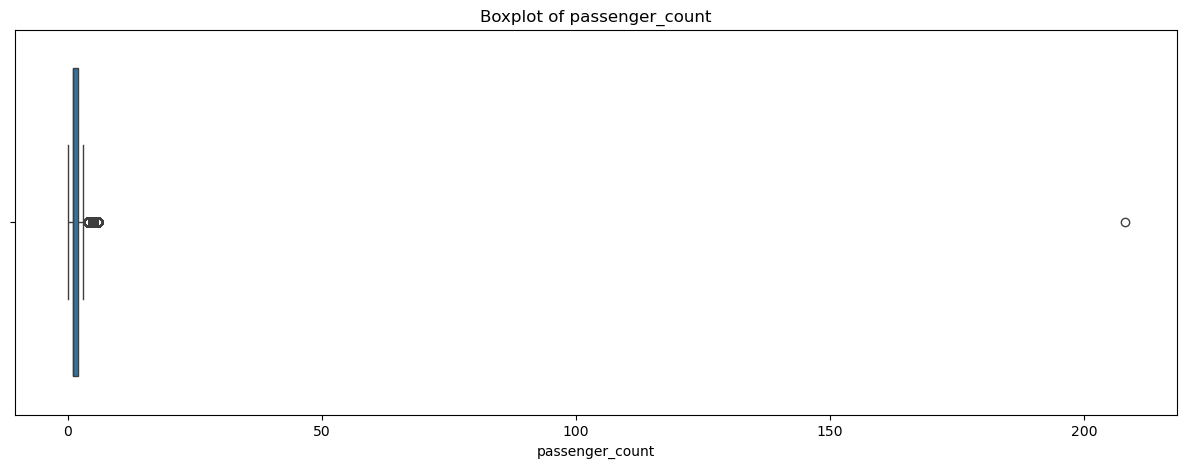

In [8]:
# Checking outliers (Before Cleaning)

print("Outliers before cleaning: ")

numerical_cols = ['fare_amount', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

for col in numerical_cols:
    plt.figure(figsize = (15,5))  # Creates a new window for each plot
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

- The boxplot of fare_amount shows a lot of outliers.
- Pickup coordinates have values far outside of New York City.
- passenger_count boxplot shows only one outlier. 

Shape of the dataset before cleaning: (200000, 9)
Checking outliers after cleaning: 


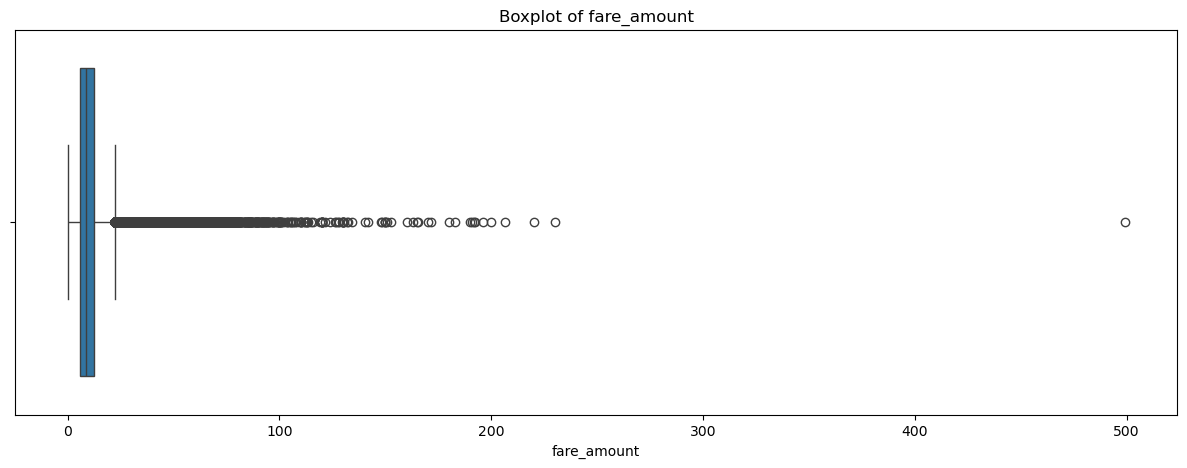

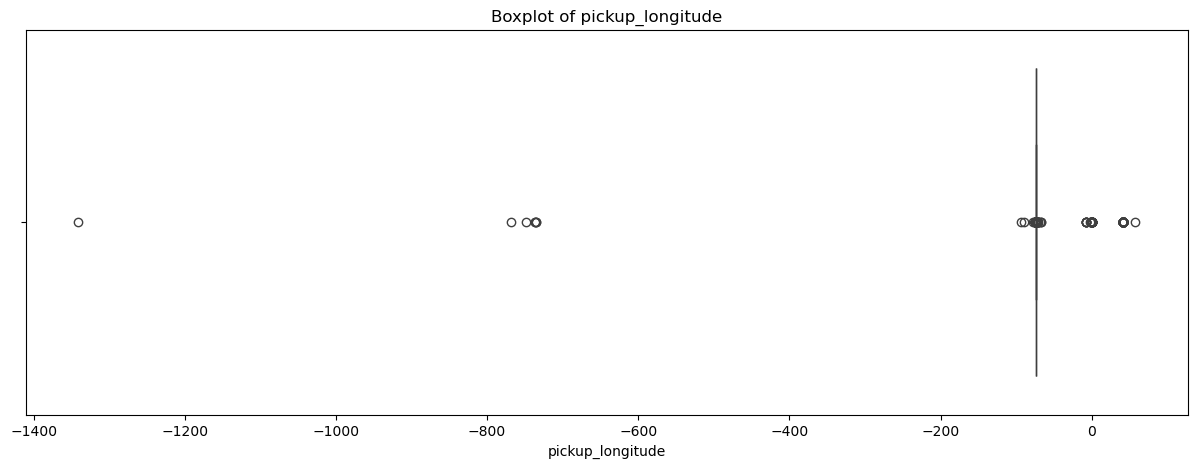

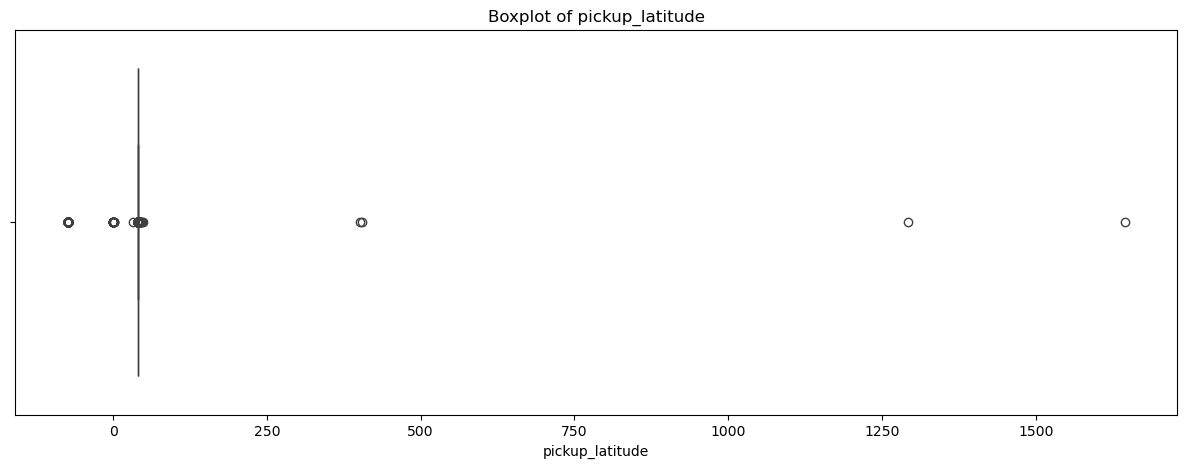

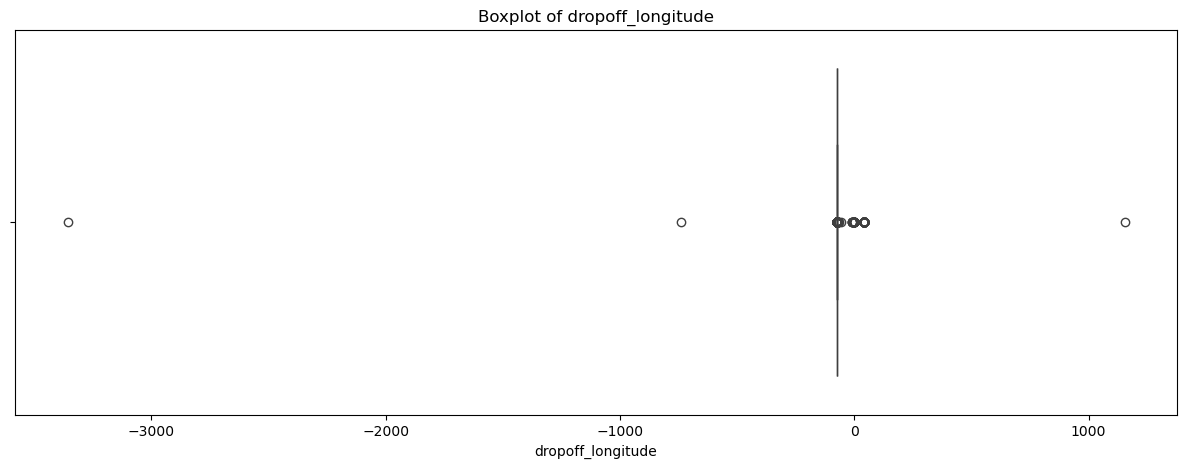

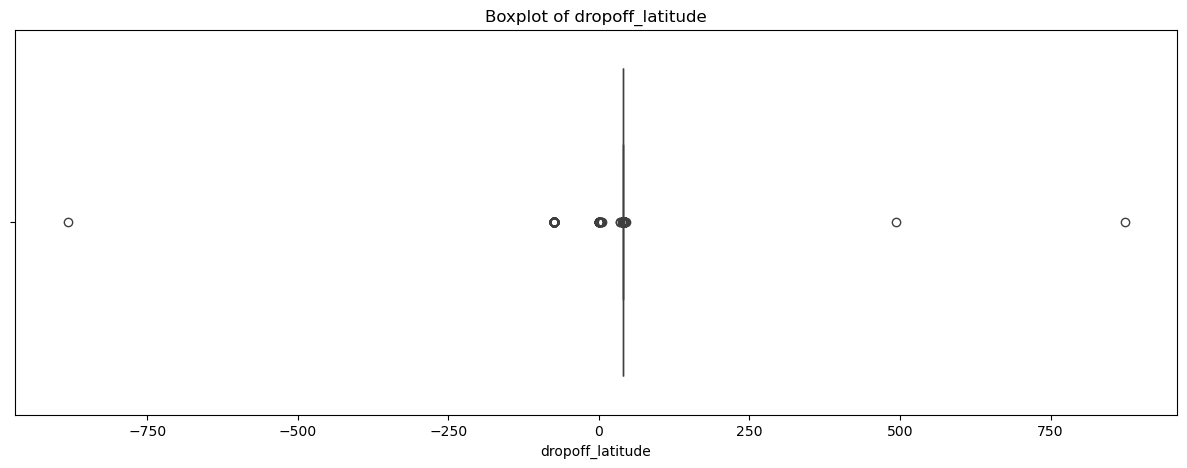

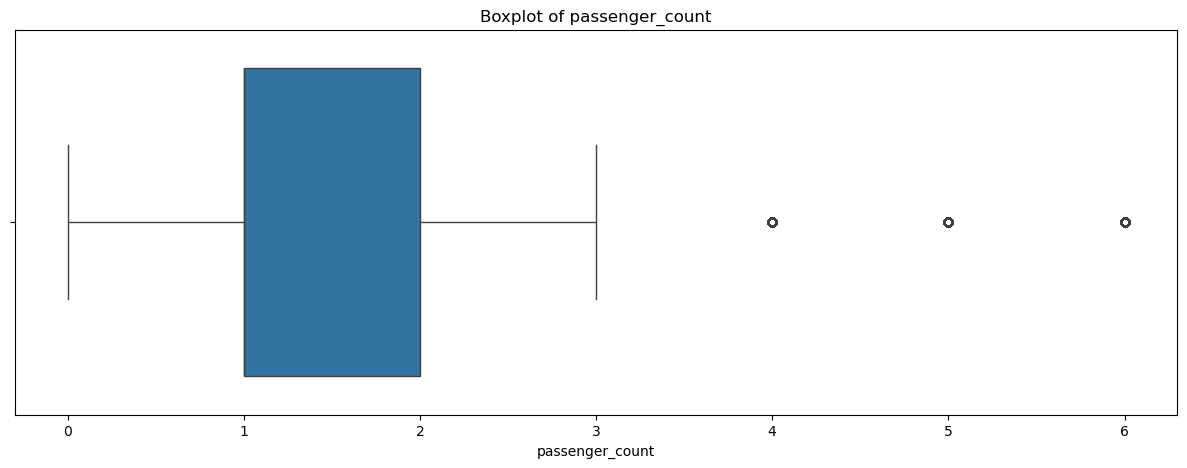

<Figure size 640x480 with 0 Axes>

Shape of the dataset after cleaning: (196019, 9)


In [9]:
# Shape of the dataset before cleaning
print(f"Shape of the dataset before cleaning: {df.shape}")

# 1. Removing rows with missing values
df = df.dropna()

# 2. Dropping duplicate rows
df = df.drop_duplicates()

# 3. Removing the rows that have invalid coordinates
cols_coor = ['pickup_longitude', 'pickup_latitude', 'dropff_longitude', 'dropoff_latitude']
for c in cols_coor:
    if c in df.columns:
        df = df[df[c] != 0]

# 4. Removing the rows with zero and negative fares
if 'fare_amount' in df.columns:
    df = df[df['fare_amount'] > 0]

# 5. Filtering the rows to New York City boundaries
NYC_BOUNDS = {'lon_min': -75, 'lon_max': -72,'lat_min':  40, 'lat_max':  42}

if set(cols_coor).issubset(df.columns):
    df = df[
        (df['pickup_longitude'].between(NYC_BOUNDS['lon_min'], NYC_BOUNDS['lon_max'])) &
        (df['dropoff_longitude'].between(NYC_BOUNDS['lon_min'], NYC_BOUNDS['lon_max'])) &
        (df['pickup_latitude'].between(NYC_BOUNDS['lat_min'], NYC_BOUNDS['lat_max'])) &
        (df['dropoff_latitude'].between(NYC_BOUNDS['lat_min'], NYC_BOUNDS['lat_max']))
    ]

# 6. Removing the outlier in passenger_count
df = df[df['passenger_count'] <= 7]

# Checking outliers (After Cleaning)
print("Checking outliers after cleaning: ")

for col in numerical_cols:
    plt.figure(figsize = (15,5))  # Creates a new window for each plot
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

plt.tight_layout()
plt.show()

# Shape of the dataset after cleaning
print(f"Shape of the dataset after cleaning: {df.shape}")

- Rows with missing values were dropped.
- Rows with duplicates were also removed even though there were none.
- Rows with zero and invalid coordinates were removed.
- Trips with negative fares also dropped.
- Data was filtered to include trips in NYC coordinates only.
- Trips with unrealistic passenger count were removed.

In [10]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


### Feature Engineering

In [11]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points on Earth.
    """
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Apply Haversine formula
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371.0
    return c * r

# Extracting time-based features from the pickup_datetime column
if 'pickup_datetime' in df.columns:
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
    df = df.dropna(subset=['pickup_datetime'])

    df['hour']    = df['pickup_datetime'].dt.hour
    df['day']     = df['pickup_datetime'].dt.day
    df['month']   = df['pickup_datetime'].dt.month
    df['weekday'] = df['pickup_datetime'].dt.weekday
    df['year']    = df['pickup_datetime'].dt.year
else:
    for col in ['hour','day','month','weekday','year']:
        df[col] = 0

# Calculating the distance feature using haversine distance
if {'pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude'}.issubset(df.columns):
    df['distance_km'] = haversine_distance(
        df['pickup_latitude'].values,
        df['pickup_longitude'].values,
        df['dropoff_latitude'].values,
        df['dropoff_longitude'].values
    )
else:
    df['distance_km'] = 0.0

# logical Consistency Check: Distance-Fare Mismatch
zero_dist_trips = df[(df['distance_km'] == 0) & (df['fare_amount'] > 0)]
print(f"Trips with 0 distance but positive fare: {len(zero_dist_trips)}")

df['is_rush_hour'] = (
    (df['weekday'] < 5) &
    (
        (df['hour'].between(7,9)) |
        (df['hour'].between(16,19))
    )
).astype(int)

df[['fare_amount','distance_km','hour','weekday','is_rush_hour']].head()

Trips with 0 distance but positive fare: 2044


,fare_amount,distance_km,hour,weekday,is_rush_hour
0,7.5,1.683323,19,3,1
1,7.7,2.457590,20,4,0
2,12.9,5.036377,21,0,0
3,5.3,1.661683,8,4,1
4,16.0,4.475450,17,3,1


- 

In [12]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,distance_km,is_rush_hour
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,7,5,3,2015,1.683323,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,17,7,4,2009,2.457590,0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,24,8,0,2009,5.036377,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,26,6,4,2009,1.661683,1
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,28,8,3,2014,4.475450,1


## Exploratory Data Analysis (EDA)

### Univariate Analysis & Visualizations

In [13]:
sns.set_style("darkgrid")

Text(0.5, 1.0, 'Trip Distance Distribution (< 50km)')

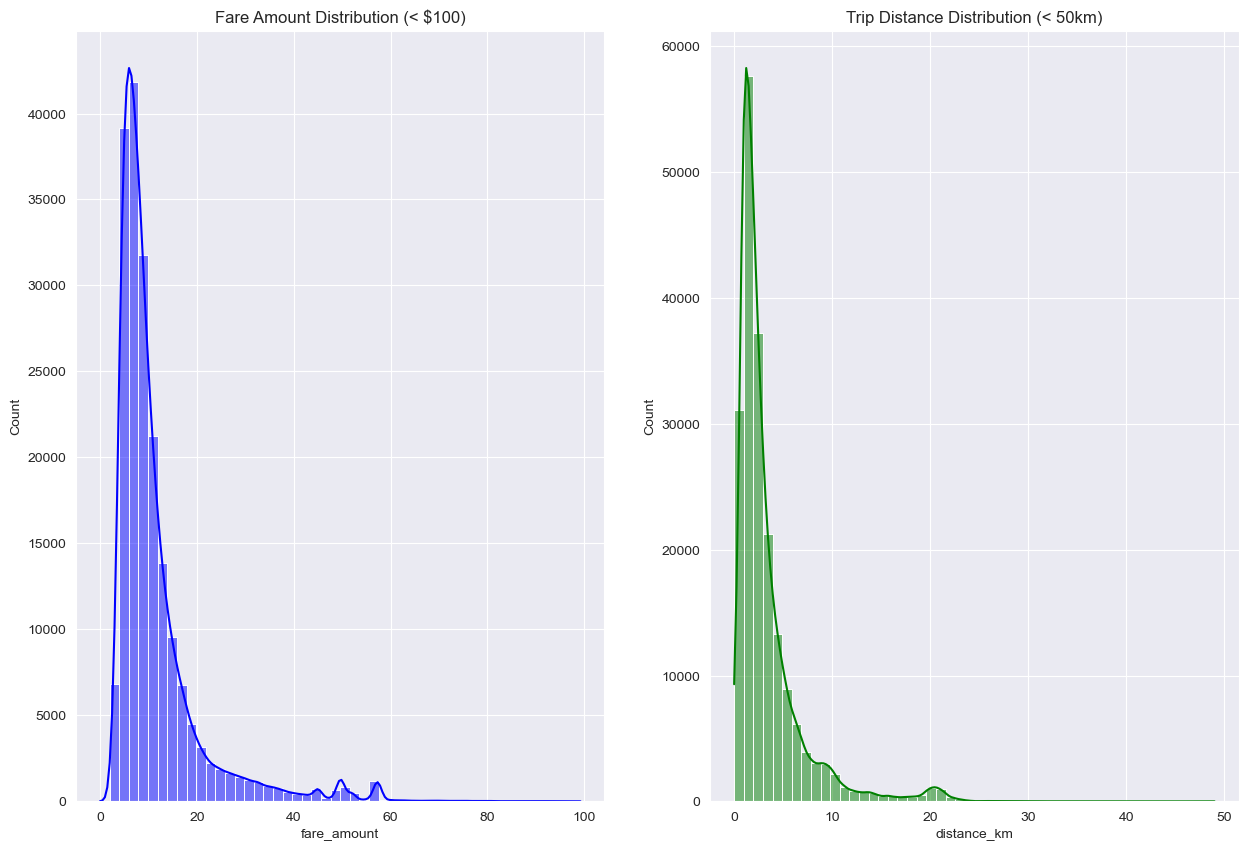

In [14]:
# Fare Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

sns.histplot(df[df['fare_amount'] < 100]['fare_amount'], bins = 50, kde = True, color = 'blue', ax = axes[0])
axes[0].set_title("Fare Amount Distribution (< $100)")

# Distance Distribution
sns.histplot(df[df['distance_km'] < 50]['distance_km'], bins = 50, kde = True, color = 'green', ax = axes[1])
axes[1].set_title("Trip Distance Distribution (< 50km)")

- The fare amounts are heavily right-skewed where most of the fares are under $20.
- The trip distances are heavily right-skewed too, with most rides under 10 km.

C:\Users\junai\AppData\Local\Temp\ipykernel_17348\2111761326.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['hour'], palette = 'magma', ax = axes[0, 1])
C:\Users\junai\AppData\Local\Temp\ipykernel_17348\2111761326.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['weekday_name'], order = order, palette = 'magma', ax = axes[1, 0])
C:\Users\junai\AppData\Local\Temp\ipykernel_17348\2111761326.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['is_rush_hour'], palette = 'Set2', ax = axes[1, 1])


Text(0.5, 1.0, 'Trips by Rush Hour')

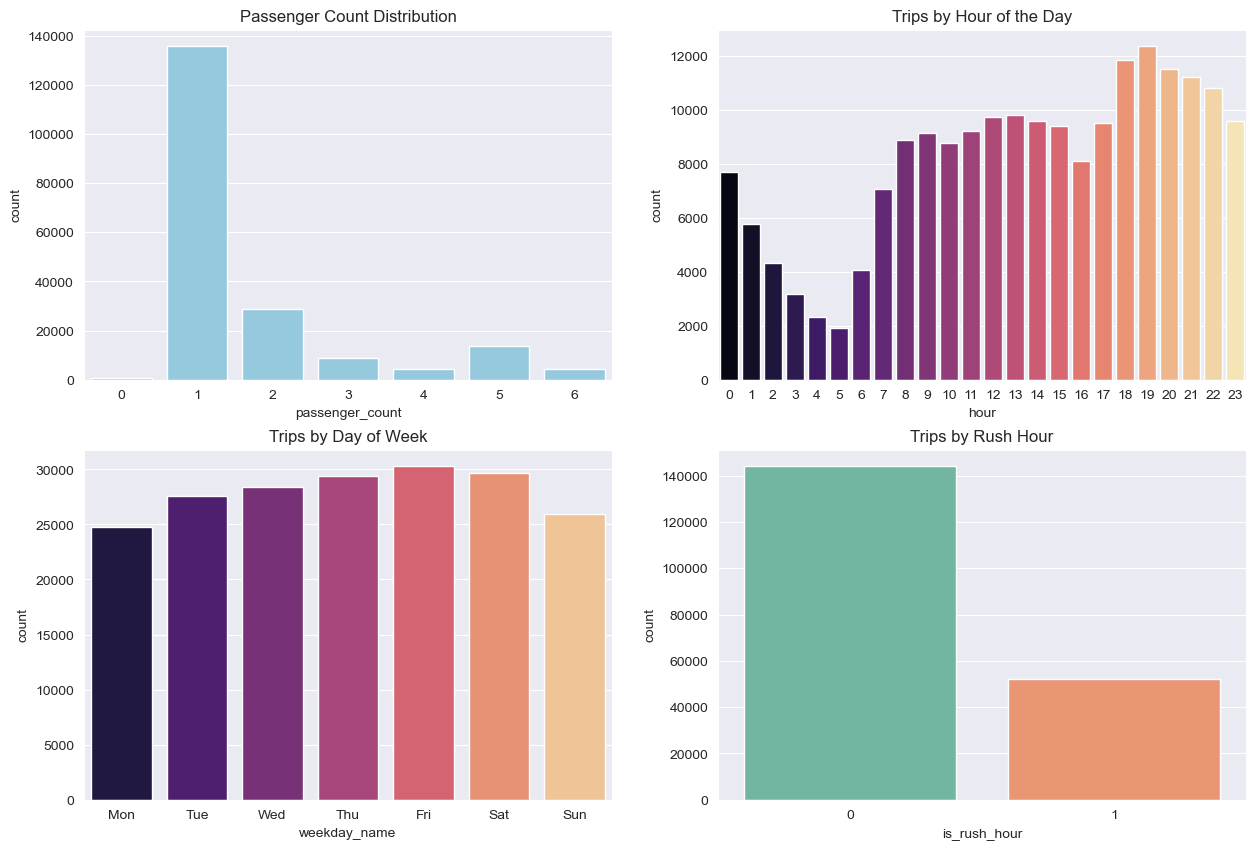

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Passenger Count Distribution
sns.countplot(x = df['passenger_count'], color = 'skyblue', ax = axes[0, 0])
axes[0, 0].set_title("Passenger Count Distribution")

# Pickup Hour Distribution
sns.countplot(x = df['hour'], palette = 'magma', ax = axes[0, 1])
axes[0, 1].set_title("Trips by Hour of the Day")

# Pickup Day Distribution
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df['weekday_name'] =df['weekday'].map(day_map)
order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.countplot(x = df['weekday_name'], order = order, palette = 'magma', ax = axes[1, 0])
axes[1, 0].set_title("Trips by Day of Week")

sns.countplot(x = df['is_rush_hour'], palette = 'Set2', ax = axes[1, 1])
axes[1, 1].set_title("Trips by Rush Hour")

- The passenger count distribution shows that the majority of rides have only 1 passenger.
- The number of trips shows a spike after 6 AM and another spike is seen from 5 PM to 7 PM. The numbers start to drop gradually thereafter. 
- There is a significant drop in trips frequency after midnight, the number of trips picking up only after 6 AM.
- Weekends (Fridays and Saturdays) show a slight increase in number of trips.
- Overall, majority of the trips during the week occuring during non-rush hours. 

### Bivariate Analysis & Visualizations

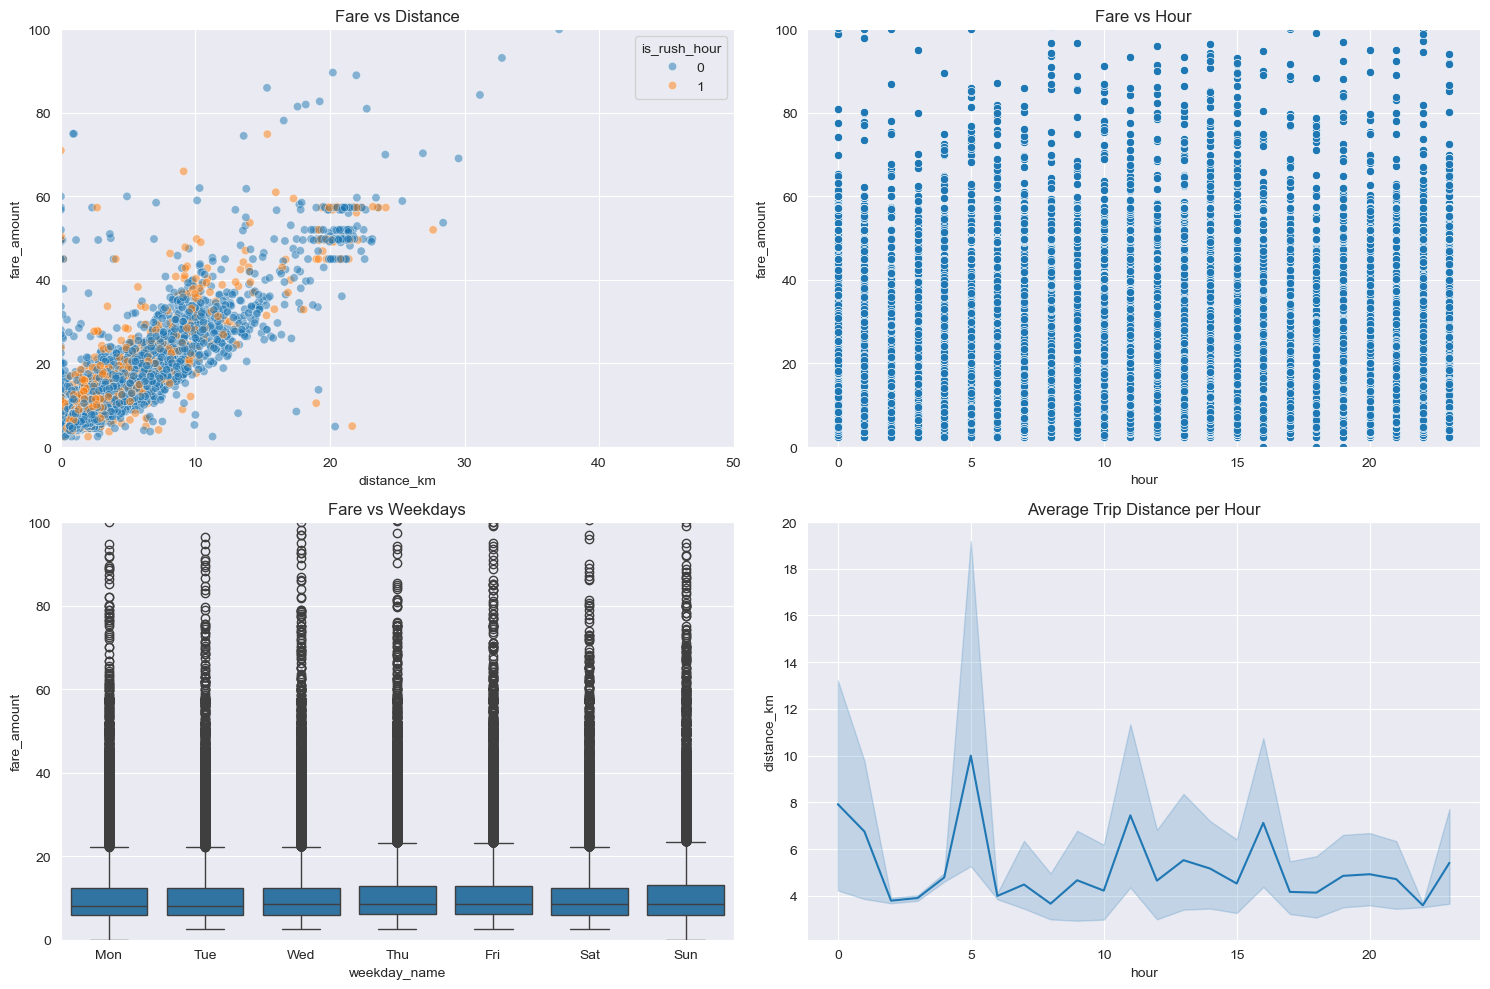

In [16]:
# Compare fare_amount with other factors (distance_km, hour and weekday)
fig, axes = plt.subplots(2, 2, figsize = (15, 10))

# Fare vs Distance
subset = df.sample(min(len(df), 10000))
sns.scatterplot(x = subset['distance_km'], y = subset['fare_amount'], hue = subset['is_rush_hour'], alpha = 0.5, ax = axes[0, 0])
axes[0, 0].set_title("Fare vs Distance")
axes[0,0].set_xlim(0, 50)
axes[0,0].set_ylim(0, 100)

# Fare vs Hour
sns.scatterplot(x = df['hour'], y = df['fare_amount'], ax = axes[0, 1])
axes[0, 1].set_title("Fare vs Hour")
axes[0, 1].set_ylim(0, 100)

# Fare vs Weekday
sns.boxplot(x = df['weekday_name'], y = df['fare_amount'], order = order, ax = axes[1, 0])
axes[1, 0].set_title("Fare vs Weekdays")
axes[1, 0].set_ylim(0, 100)

# Distance vs Hour
sns.lineplot(x = df['hour'], y = df['distance_km'], ax = axes[1, 1])
axes[1, 1].set_title("Average Trip Distance per Hour")

plt.tight_layout()
plt.show()

- The scatterplot between distance_km and fare_amount shows that there is a strong positive relationship between these features.
- Fare distribution by hour is stable and outliers are present in all hours.
- Fare distribution by weekdays shows that it's same for all the days.
- The average trip distance is highest at 5 AM, then goes down during the day hours and picks up at late night. 

### Correlation Matrix

Generating Correlation Matrix...


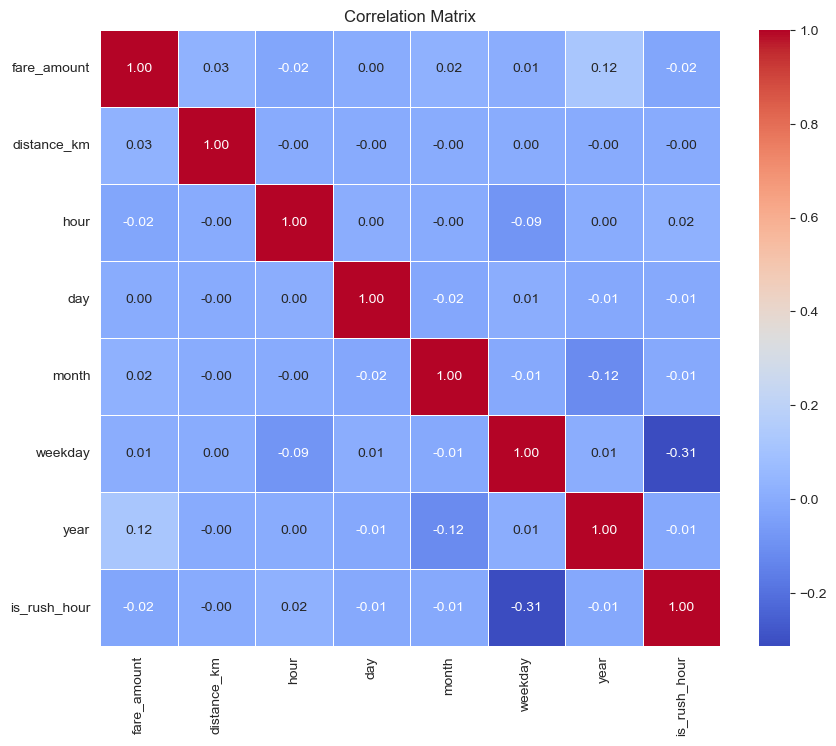

In [17]:
print("Generating Correlation Matrix...")
plt.figure(figsize=(10, 8))
numeric_cols = ['fare_amount', 'distance_km', 'hour', 'day', 'month', 'weekday', 'year', 'is_rush_hour']
corr_matrix = df[numeric_cols].corr()

# Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [18]:
# Correlations with fare_amount
print("The top correlations with Fare Amount: ")
print(corr_matrix['fare_amount'].sort_values(ascending = False).head(10))

The top correlations with Fare Amount: 
fare_amount     1.000000
year            0.118685
distance_km     0.028266
month           0.023941
weekday         0.006595
day             0.000558
hour           -0.020861
is_rush_hour   -0.021110
Name: fare_amount, dtype: float64


The features: year and distance_km have positive correlations with the fare_amount feature among which distance_km is significant. It can be considered the main factor of fare. 

### Train-Test Split

In [19]:
# Train Test Split

target = 'fare_amount'

feature_cols = ['distance_km', 'hour', 'weekday', 'is_rush_hour']

if 'passenger_count' in df.columns and df['passenger_count'].notna().any():
    feature_cols.append('passenger_count')

X = df[feature_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = RANDOM_STATE
)

In [20]:
X_train.shape, X_test.shape

((156815, 5), (39204, 5))

In [21]:
y_train.shape, y_test.shape

((156815,), (39204,))

### Machine Learning Modeling

Linear Regression

In [22]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

rmse_lr = float(np.sqrt(mean_squared_error(y_test, pred_lr)))
r2_lr = float(r2_score(y_test, pred_lr))

print("Linear Regression Results: ")
print(f"RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")

Linear Regression Results: 
RMSE: 10.0375, R2: 0.0018


In [23]:
# Random Forest Regressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rmse_rf = float(np.sqrt(mean_squared_error(y_test, pred_rf)))
r2_rf = float(r2_score(y_test, pred_rf))

print("Random Forest Regressor Results: ")
print(f"RMSE: {rmse_rf:.4f}, R2: {r2_rf:.4f}")

Random Forest Regressor Results: 
RMSE: 5.5242, R2: 0.6976


In [24]:
# XGBoost Regressor
xgb_reg = xgb.XGBRegressor()
xgb_reg.fit(X_train, y_train)
pred_xgb = xgb_reg.predict(X_test)

rmse_xgb = float(np.sqrt(mean_squared_error(y_test, pred_xgb)))
r2_xgb = float(r2_score(y_test, pred_xgb))

print("Random Forest Regressor Results: ")
print(f"RMSE: {rmse_xgb:.4f}, R2: {r2_xgb:.4f}")

Random Forest Regressor Results: 
RMSE: 5.5764, R2: 0.6919


- Linear Regression is the worst performer with RMSE of 10.03 and lowest R2 score of 0.0018.
- Random Forest Regressor is the best overall performer
- XGBoost performs slightly worst than Random Forest Regressor but it is better than Linear Regression.

### Hyperparameter Tuning

In [25]:
# Hyperparameter Tuning for Random Forest Regressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state = RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print('Best parameters: ', grid_search.best_params_)

print('Best CV RMSE: ', -grid_search.best_score_)

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)
best_rf_rmse = float(np.sqrt(mean_squared_error(y_pred, y_test)))
best_rf_r2 = float(r2_score(y_pred, y_test))

print("Values of RMSE and R2 after fine-tuning: ")
print(f"RMSE: {best_rf_rmse: .4f}, R2: {best_rf_r2: .4f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters:  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best CV RMSE:  -22.740269201331817
Values of RMSE and R2 after fine-tuning: 
RMSE:  5.3348, R2:  0.5692


- The hyperparameter and grid search shows that the best features are:
- The best cross-validate RMSE is
- RMSE of the model after fine-tuning is 5.3348 which is better than untuned model RMSE which was 5.5242. 
- R2 score of the model after fine-tuning is 0.5692 which is again better than R2 of untuned model which was 0.6976. 

In [28]:
# Hyperparameter Tuning for XGBoost Regressor

### Final Findings

- Distance plays a great role in predicting trip prices, this is confirmed by correlation and graphs.
- Other features like hour, day, weekday, passenger count don't contribute much in fare prediction.
- The fare and distance data is right-skewed, most trips were under $10 and covered less than 10 km.
- Trips were higher during the rush hours and low during and after midnight. 
- Random Forest and XGBoost models performed better than Linear Regression, showing their ability to capture non-linear relationships.
- The fine-tuned Random Forest model achieved an RMSE of 5.3348 and R2 0.5692.